In [0]:
reviews_df = spark.read.parquet(
"/Volumes/project/project/project/Video_Games.parquet"
)

reviews_df.printSchema()
reviews_df.show(5)

root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- small_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- attachment_type: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

+------+--------------------+--------------------+------+----------+-----------+--------------------+-------------+------------+-----------------+
|rating|               title|                text|images|      asin|parent_asin|             user_id|    timestamp|helpful_vote|verified_purchase|
+------+------------------

In [0]:
import pyarrow.parquet as pq
import pandas as pd

# Use PyArrow to read the Parquet file and handle duplicate columns
parquet_path = "/Volumes/project/project/project/meta_Video_Games.parquet"
table = pq.read_table(parquet_path)

# Deduplicate column names
cols = table.column_names
seen = {}
deduped_cols = []

for c in cols:
    if c in seen:
        seen[c] += 1
        deduped_cols.append(f"{c}_{seen[c]}")
    else:
        seen[c] = 0
        deduped_cols.append(c)

# Create pandas DataFrame with deduplicated columns
pandas_df = table.to_pandas()
pandas_df.columns = deduped_cols

# Convert to Spark DataFrame
meta_df = spark.createDataFrame(pandas_df)

print(meta_df.columns)

['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [0]:
reviews_df.show(5, truncate=False)

+------+------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------+-----------+----------------------------+-------------+------------+-----------------+
|rating|title                                                                   |text                                                                                                                                                                                                                              |images|asin      |parent_asin|user_id                     |timestamp    |helpful_vote|verified_purchase|
+------+------------------------------------------------------------------------+---------------------------------------------------------------------------------------------

In [0]:
meta_df.printSchema()

root
 |-- main_category: string (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- hi_res: string (nullable = true)
 |    |    |-- large: string (nullable = true)
 |    |    |-- thumb: string (nullable = true)
 |    |    |-- variant: string (nullable = true)
 |-- videos: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- title: string (nullable = true)
 |    |    |-- url: string (nullable = true)
 |    |    |-- user_id: string (nullable = true)
 |-- store: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (con

In [0]:
meta_df.show(10, truncate=False)

+-------------+--------------------------------------------------------------------------------------------------------------------------------------------------+--------------+-------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [0]:
print("Reviews Rows:", reviews_df.count())
print("Meta Rows:", meta_df.count())

Reviews Rows: 4624615
Meta Rows: 137269


In [0]:
print("Reviews Columns:", len(reviews_df.columns))
print("Meta Columns:", len(meta_df.columns))

Reviews Columns: 10
Meta Columns: 16


In [0]:
from pyspark.sql.functions import rand

sample_df = reviews_df.orderBy(rand()).limit(5000)

In [0]:
sample_df.count()

5000

In [0]:
from pyspark.sql.functions import *

sample_df.select([
    count(when(col(c).isNull(),c)).alias(c)
    for c in sample_df.columns
]).show()

+------+-----+----+------+----+-----------+-------+---------+------------+-----------------+
|rating|title|text|images|asin|parent_asin|user_id|timestamp|helpful_vote|verified_purchase|
+------+-----+----+------+----+-----------+-------+---------+------------+-----------------+
|     0|    0|   0|     0|   0|          0|      0|        0|           0|                0|
+------+-----+----+------+----+-----------+-------+---------+------------+-----------------+



In [0]:
sample_df.printSchema()

root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- small_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- attachment_type: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [0]:
sample_df = sample_df.withColumn(
    "review_date",
    from_unixtime(col("timestamp")/1000)
)

In [0]:
sample_df = sample_df.withColumn(
    "review_date",
    to_timestamp("review_date")
)

In [0]:
sample_df.select(
    "timestamp",
    "review_date"
).show(5)

+-------------+-------------------+
|    timestamp|        review_date|
+-------------+-------------------+
|1348063117000|2012-09-19 13:58:37|
|1525397688778|2018-05-04 01:34:48|
|1427045992000|2015-03-22 17:39:52|
|1673872617854|2023-01-16 12:36:57|
|1616533291547|2021-03-23 21:01:31|
+-------------+-------------------+
only showing top 5 rows


In [0]:
full_df = sample_df.join(
    meta_df,
    on="parent_asin",
    how="left"
)

In [0]:
full_df.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- small_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- attachment_type: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- review_date: timestamp (nullable = true)
 |-- main_category: string (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description:

In [0]:
full_df.groupBy("rating")\
       .count()\
       .orderBy("rating")\
       .show()

+------+-----+
|rating|count|
+------+-----+
|   1.0|  658|
|   2.0|  260|
|   3.0|  350|
|   4.0|  631|
|   5.0| 3101|
+------+-----+



In [0]:
full_df.groupBy("verified_purchase")\
       .count()\
       .show()

+-----------------+-----+
|verified_purchase|count|
+-----------------+-----+
|             true| 4332|
|            false|  668|
+-----------------+-----+



In [0]:
from pyspark.sql.functions import year

full_df.groupBy(
    year("review_date").alias("year")
).count().orderBy("year").show()

+----+-----+
|year|count|
+----+-----+
|2000|    2|
|2001|    7|
|2002|   11|
|2003|   18|
|2004|   16|
|2005|   13|
|2006|   20|
|2007|   29|
|2008|   36|
|2009|   64|
|2010|   58|
|2011|  103|
|2012|  123|
|2013|  282|
|2014|  365|
|2015|  451|
|2016|  404|
|2017|  390|
|2018|  376|
|2019|  523|
+----+-----+
only showing top 20 rows


In [0]:
full_df = full_df.withColumn(
    "sentiment",
    when(col("rating")>=4,1).otherwise(0)
)

MY new work of EDA 

In [0]:
from pyspark.sql.functions import avg, count, desc

full_df.groupBy("parent_asin") \
    .agg(
        avg("rating").alias("Average_Rating"),
        count("*").alias("Total_Reviews")
    ) \
    .orderBy(desc("Average_Rating")) \
    .show(20, truncate=False)

+-----------+--------------+-------------+
|parent_asin|Average_Rating|Total_Reviews|
+-----------+--------------+-------------+
|B005XT33NY |5.0           |1            |
|B001EYUTMA |5.0           |1            |
|B07C91PXNM |5.0           |3            |
|B0BP6HRHL6 |5.0           |1            |
|B0000A09EL |5.0           |1            |
|B0BFT941YQ |5.0           |2            |
|B072K73141 |5.0           |1            |
|B00L99WZFY |5.0           |1            |
|B003ANMB6A |5.0           |2            |
|B01J4JYBBQ |5.0           |1            |
|B08QCW98WD |5.0           |1            |
|B07PQYV1J5 |5.0           |1            |
|B07F7XWVMQ |5.0           |1            |
|B001QCWSEW |5.0           |1            |
|B004KKG186 |5.0           |1            |
|B07WTBZNTN |5.0           |1            |
|B011ILD9ZM |5.0           |1            |
|B07SM7G9CN |5.0           |1            |
|B0C1K1R6HK |5.0           |1            |
|B0B2QK1R89 |5.0           |1            |
+----------

In [0]:
full_df.groupBy("parent_asin") \
    .count() \
    .orderBy(desc("count")) \
    .show(20, truncate=False)

+-----------+-----+
|parent_asin|count|
+-----------+-----+
|B01N3ASPNV |28   |
|B0BN942894 |25   |
|B0086VPUHI |18   |
|B07V8YSBFG |13   |
|B07YBXFDYN |13   |
|B00E5UHSX8 |12   |
|B077GG9D5D |11   |
|B005GFPZYK |11   |
|B07WSHTJ48 |10   |
|B0883P3VSH |10   |
|B08LT6PT1X |10   |
|B081243BT6 |10   |
|B000N5Z2L4 |10   |
|B004RMK5QG |9    |
|B00BN5T30E |9    |
|B00BGA9WK2 |9    |
|B0C5K4M7WJ |8    |
|B00AAS888S |8    |
|B0029LJIFG |8    |
|B00HBUOVIO |8    |
+-----------+-----+
only showing top 20 rows


In [0]:
from pyspark.sql.functions import avg

full_df.groupBy("rating") \
    .agg(
        avg("helpful_vote").alias("Average_Helpful_Votes")
    ) \
    .orderBy("rating") \
    .show()

+------+---------------------+
|rating|Average_Helpful_Votes|
+------+---------------------+
|   1.0|   1.8389057750759878|
|   2.0|   1.2076923076923076|
|   3.0|   1.0457142857142858|
|   4.0|   1.2393026941362917|
|   5.0|   0.7903901967107385|
+------+---------------------+



Till here 

In [0]:
full_df.groupBy("sentiment").count().show()

+---------+-----+
|sentiment|count|
+---------+-----+
|        1| 3732|
|        0| 1268|
+---------+-----+



In [0]:
text_df = full_df.select(
    "text",
    "sentiment"
).dropna()

In [0]:
# Convert to pandas for sklearn processing
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import re

text_pandas = text_df.toPandas()

In [0]:
import re

text_pandas['text'] = (
    text_pandas['text']
    .astype(str)
    .apply(
        lambda x:
        re.sub(r'<.*?>',' ',x)
    )
)

In [0]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    stop_words='english',
    min_df=5
)

analyzer = cv.build_analyzer()

text_pandas['clean_text'] = (
    text_pandas['text']
    .apply(
        lambda x:
        " ".join(analyzer(x))
    )
)

In [0]:
clean_df = text_pandas

In [0]:
print(clean_df)

                                                   text  ...                                         clean_text
0                                             good game  ...                                          good game
1                                                  good  ...                                               good
2     It fit right on the controller. Looks great. N...  ...  fit right controller looks great travel challe...
3                                         Worked great!  ...                                       worked great
4     My son said some parts are bendy like his arms...  ...  son said parts bendy like arms works fun use f...
...                                                 ...  ...                                                ...
4995  Was recieved in a damaged parcel, one peice wa...  ...  recieved damaged parcel peice missing return p...
4996  I have played C&C since the very first incarna...  ...  played incarnation played rts title incept

In [0]:
X_count = cv.fit_transform(
    clean_df['clean_text']
)

In [0]:
idx = 100

print("Original:")
print(clean_df['text'].iloc[idx])

print("\nAfter Stopword Removal:")
print(clean_df['clean_text'].iloc[idx])

Original:
Work just fine was extremely please with this product will be getting more for my other computer soon

After Stopword Removal:
work just fine extremely product getting computer soon


In [0]:
print("Original Text:")
print(clean_df['text'].iloc[2])


Original Text:
It fit right on the controller. Looks great. Now its the travel challenge controller. I need to get a bowling ball bag for it, or a violin case.


In [0]:
print("\nAfter Stopword Removal:")
print(clean_df['clean_text'].iloc[2])


After Stopword Removal:
fit right controller looks great travel challenge controller need bowling ball bag violin case


In [0]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(
    clean_df['clean_text']
)

In [0]:
y = clean_df['sentiment']

In [0]:
from sklearn.model_selection import train_test_split

y = clean_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 13475)
(1000, 13475)


In [0]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [0]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test,y_pred_nb))
print("Precision:", precision_score(y_test,y_pred_nb))
print("Recall   :", recall_score(y_test,y_pred_nb))
print("F1 Score :", f1_score(y_test,y_pred_nb))

Accuracy : 0.758
Precision: 0.756811301715439
Recall   : 0.9986684420772304
F1 Score : 0.8610792192881745


In [0]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

In [0]:
print("Accuracy :", accuracy_score(y_test,y_pred_lr))
print("Precision:", precision_score(y_test,y_pred_lr))
print("Recall   :", recall_score(y_test,y_pred_lr))
print("F1 Score :", f1_score(y_test,y_pred_lr))

Accuracy : 0.826
Precision: 0.8201997780244173
Recall   : 0.9840213049267643
F1 Score : 0.8946731234866828


In [0]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

In [0]:
print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("Recall   :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))

Accuracy : 0.83
Precision: 0.8260381593714927
Recall   : 0.9800266311584553
F1 Score : 0.8964677222898904


In [0]:
comparison = pd.DataFrame({
    'Model':['Naive Bayes',
             'Logistic Regression',
             'Random Forest'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_nb),
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ],
    'F1 Score':[
        f1_score(y_test,y_pred_nb),
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Naive Bayes,0.758,0.861079
1,Logistic Regression,0.826,0.894673
2,Random Forest,0.830,0.896468


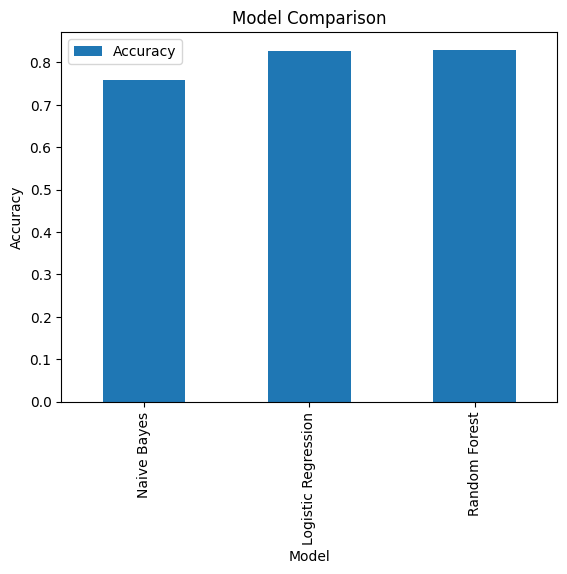

In [0]:
import matplotlib.pyplot as plt

comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [0]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm)

[[ 87 162]
 [ 12 739]]


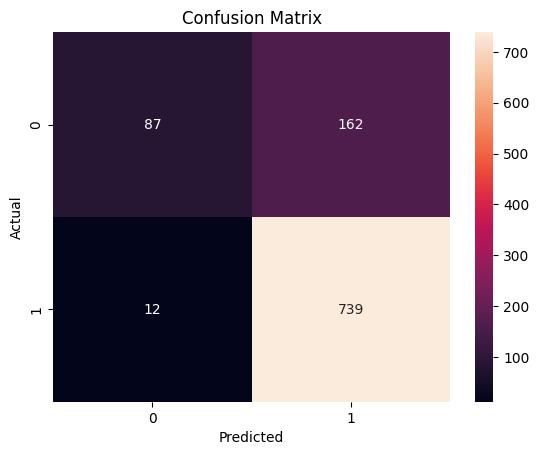

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [0]:
coef = lr.coef_[0]

feature_names = tfidf.get_feature_names_out()

importance = pd.DataFrame({
    'word':feature_names,
    'coefficient':coef
})

top_positive = importance.sort_values(
    'coefficient',
    ascending=False
).head(20)

print(top_positive)

            word  coefficient
5420       great     5.132459
7153        love     4.040783
7159       loves     2.820512
5022         fun     2.375050
13286      works     2.362670
8639     perfect     2.342700
1125     awesome     2.336534
4305   excellent     2.286030
1396        best     2.192824
5320        good     2.178228
5598       happy     2.066984
737      amazing     1.989088
8643   perfectly     1.856126
3928        easy     1.800501
4714        fits     1.602181
7154       loved     1.588061
7997        nice     1.504262
9599      really     1.451949
4290     exactly     1.413645
12031      thank     1.357457


In [0]:
top_negative = importance.sort_values(
    'coefficient'
).head(20)

print(top_negative)

               word  coefficient
3424           didn    -2.695597
13277          work    -2.666136
11482       stopped    -2.414494
3666            don    -2.388817
3642          doesn    -2.366505
10052        return    -2.360665
1722          broke    -2.117088
5903       horrible    -2.056347
3505   disappointed    -2.033669
1723         broken    -1.990737
3422            did    -1.974880
7753         months    -1.848572
13050         waste    -1.844409
12380         tried    -1.708989
2135          cheap    -1.697094
13302        wouldn    -1.668250
6591           junk    -1.634061
13283       working    -1.624290
7729          money    -1.605752
13107         weeks    -1.590009


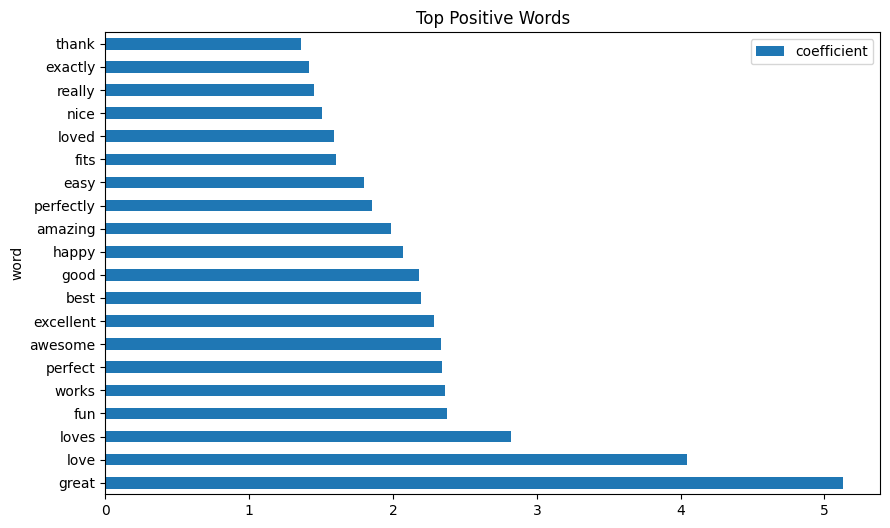

In [0]:
top_positive.plot(
    x='word',
    y='coefficient',
    kind='barh',
    figsize=(10,6)
)

plt.title("Top Positive Words")
plt.show()

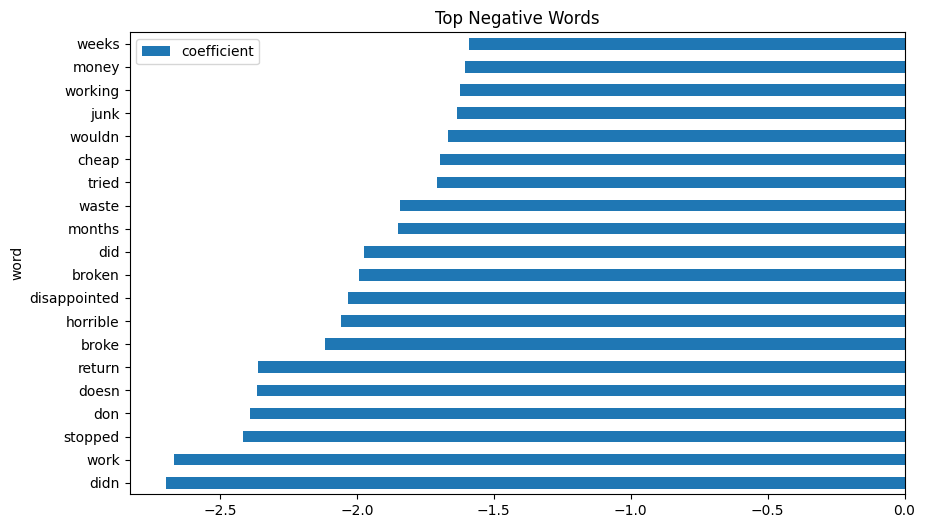

In [0]:
top_negative.plot(
    x='word',
    y='coefficient',
    kind='barh',
    figsize=(10,6)
)

plt.title("Top Negative Words")
plt.show()

In [0]:
clean_df['review_length'] = (
    clean_df['clean_text']
    .apply(len)
)

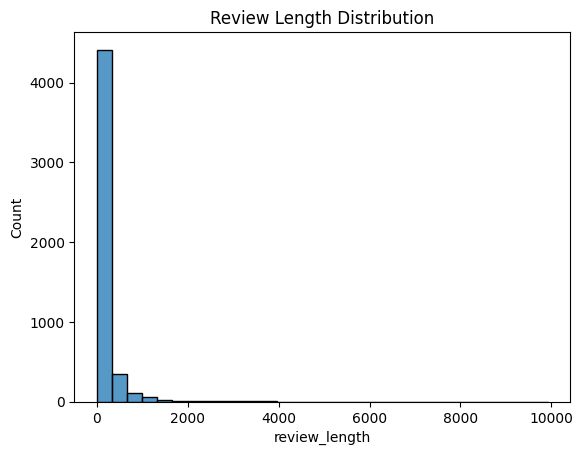

In [0]:
import seaborn as sns

sns.histplot(
    clean_df['review_length'],
    bins=30
)

plt.title("Review Length Distribution")
plt.show()

In [0]:
clean_df['sentiment'].value_counts()

sentiment
1    3756
0    1244
Name: count, dtype: int64

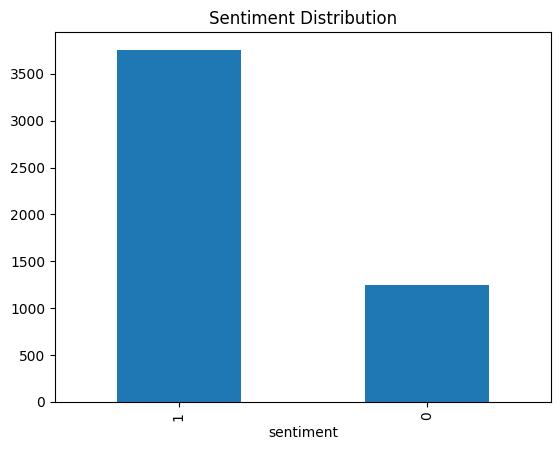

In [0]:
clean_df['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Distribution")
plt.show()

In [0]:
# Transformer-Based Sentiment Analysis (DistilBERT)

In [0]:
%pip install transformers torch

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from transformers import pipeline

/local_disk0/.ephemeral_nfs/envs/pythonEnv-17c756ab-ac69-438b-b8a0-1f2f90e1678d/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten


In [0]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [0]:
sample_review = clean_df['text'].iloc[0]

result = sentiment_model(
    sample_review[:512]
)

print(result)

[{'label': 'POSITIVE', 'score': 0.9998469352722168}]


In [0]:
sample_df = clean_df.sample(
    500,
    random_state=42
)

reviews = sample_df['text'].tolist()

predictions = sentiment_model(
    [review[:512] for review in reviews]
)

In [0]:
bert_pred = []

for pred in predictions:

    if pred['label'] == 'POSITIVE':
        bert_pred.append(1)

    else:
        bert_pred.append(0)

In [0]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

y_true = sample_df['sentiment']

bert_acc = accuracy_score(y_true, bert_pred)
bert_precision = precision_score(y_true, bert_pred)
bert_recall = recall_score(y_true, bert_pred)
bert_f1 = f1_score(y_true, bert_pred)

print("Accuracy :", bert_acc)
print("Precision:", bert_precision)
print("Recall   :", bert_recall)
print("F1 Score :", bert_f1)

Accuracy : 0.852
Precision: 0.9320113314447592
Recall   : 0.8680738786279684
F1 Score : 0.8989071038251366


In [0]:
nb_acc = accuracy_score(y_test, y_pred_nb)
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

comparison

,Model,Accuracy,F1 Score
0,Naive Bayes,0.758,0.861079
1,Logistic Regression,0.826,0.894673
2,Random Forest,0.830,0.896468


In [0]:
comparison = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression',
        'Random Forest',
        'DistilBERT'
    ],
    'Accuracy': [
        nb_acc,
        lr_acc,
        rf_acc,
        bert_acc
    ]
})

comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
3,DistilBERT,0.852
2,Random Forest,0.830
1,Logistic Regression,0.826
0,Naive Bayes,0.758


In [0]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)

In [0]:
sample_review = clean_df['text'].iloc[0]

print(sample_review)

good game


In [0]:
tokens = tokenizer.tokenize(sample_review)

print(tokens[:100])

['good', 'game']


In [0]:
token_ids = tokenizer.encode(
    sample_review,
    add_special_tokens=True
)

print(token_ids[:50])

[101, 2204, 2208, 102]


In [0]:
ids = tokenizer.encode(
    sample_review,
    add_special_tokens=True
)

tokens = tokenizer.convert_ids_to_tokens(ids)

for token in tokens[:50]:
    print(token)

[CLS]
good
game
[SEP]


In [0]:
text = "unbelievable gameplay"

tokens = tokenizer.tokenize(text)

print(tokens)

['unbelievable', 'gameplay']


In [0]:
sample_reviews = clean_df.sample(
    10,
    random_state=42
)[['text','sentiment']]

for idx, row in sample_reviews.iterrows():

    review = str(row['text'])[:512]

    prediction = sentiment_model(review)[0]

    actual = "POSITIVE" if row['sentiment']==1 else "NEGATIVE"

    print("="*120)

    print("Review:")
    print(review[:300])

    print("\nActual Sentiment:")
    print(actual)

    print("\nPredicted Sentiment:")
    print(prediction['label'])

    print("\nConfidence:")
    print(f"{prediction['score']:.4f}")

Review:
87ughiojpk

Actual Sentiment:
POSITIVE

Predicted Sentiment:
NEGATIVE

Confidence:
0.8938
Review:
Charger works well however it only came with a usb charging cable, was expecting to plug it into an electrical outlet. But so far the charger is working as it should

Actual Sentiment:
POSITIVE

Predicted Sentiment:
POSITIVE

Confidence:
0.9886
Review:
If you are buying this to get the charging cord, you're in luck. It works perfectly with both the Xbox 360 and a PC. If you need the battery, don't. Just don't. It's a waste of time and was successful in holding a charge only long enough to sync the controller, then it died.

Actual Sentiment:
NEGATIVE

Predicted Sentiment:
NEGATIVE

Confidence:
0.9978
Review:
the range of the headset is horrible if you plan on walking around with the headset, the audio was fading in and out on my right side, while gaming I would get a garbled sound effects from time to time. Ended up actually going back to my old head set and just re-ordered a Artic

In [0]:
hard_reviews = [
    "The product is excellent but stopped working after one week",
    "The game has amazing graphics but the controls are terrible",
    "I loved the design but the battery life is awful",
    "The sound quality is fantastic but it crashes frequently",
    "The product works well although customer support is useless"
]

results = sentiment_model(hard_reviews)

for review, result in zip(hard_reviews, results):
    print("="*100)
    print("Review:", review)
    print("Prediction:", result['label'])
    print("Confidence:", f"{result['score']:.4f}")

Review: The product is excellent but stopped working after one week
Prediction: NEGATIVE
Confidence: 0.9766
Review: The game has amazing graphics but the controls are terrible
Prediction: NEGATIVE
Confidence: 0.9913
Review: I loved the design but the battery life is awful
Prediction: NEGATIVE
Confidence: 0.9991
Review: The sound quality is fantastic but it crashes frequently
Prediction: NEGATIVE
Confidence: 0.9457
Review: The product works well although customer support is useless
Prediction: POSITIVE
Confidence: 0.8585


In [0]:
hard_reviews = [
    "The product is not good",
    "The product is not bad",
    "I do not dislike this game",
    "I am not unhappy with this purchase",
    "The product is not terrible"
]

results = sentiment_model(hard_reviews)

print("\nNEGATION REVIEWS")
print("="*100)

for review, result in zip(hard_reviews, results):
    print("\nReview:")
    print(review)

    print("\nPrediction:")
    print(result['label'])

    print("\nConfidence:")
    print(f"{result['score']:.4f}")

    print("-"*100)


NEGATION REVIEWS

Review:
The product is not good

Prediction:
NEGATIVE

Confidence:
0.9998
----------------------------------------------------------------------------------------------------

Review:
The product is not bad

Prediction:
POSITIVE

Confidence:
0.9991
----------------------------------------------------------------------------------------------------

Review:
I do not dislike this game

Prediction:
POSITIVE

Confidence:
0.9890
----------------------------------------------------------------------------------------------------

Review:
I am not unhappy with this purchase

Prediction:
POSITIVE

Confidence:
0.9966
----------------------------------------------------------------------------------------------------

Review:
The product is not terrible

Prediction:
POSITIVE

Confidence:
0.9927
----------------------------------------------------------------------------------------------------


In [0]:
hard_reviews = [
    "Fantastic, it broke on the first day",
    "Great job, now the product won't even turn on",
    "Wonderful experience, I wasted my money",
    "Amazing quality, lasted only two hours",
    "Best purchase ever... not"
]

results = sentiment_model(hard_reviews)

print("\nSARCASM REVIEWS")
print("="*100)

for review, result in zip(hard_reviews, results):
    print("\nReview:")
    print(review)

    print("\nPrediction:")
    print(result['label'])

    print("\nConfidence:")
    print(f"{result['score']:.4f}")

    print("-"*100)


SARCASM REVIEWS

Review:
Fantastic, it broke on the first day

Prediction:
POSITIVE

Confidence:
0.9999
----------------------------------------------------------------------------------------------------

Review:
Great job, now the product won't even turn on

Prediction:
NEGATIVE

Confidence:
0.9905
----------------------------------------------------------------------------------------------------

Review:
Wonderful experience, I wasted my money

Prediction:
NEGATIVE

Confidence:
0.9655
----------------------------------------------------------------------------------------------------

Review:
Amazing quality, lasted only two hours

Prediction:
POSITIVE

Confidence:
0.9985
----------------------------------------------------------------------------------------------------

Review:
Best purchase ever... not

Prediction:
POSITIVE

Confidence:
0.9991
----------------------------------------------------------------------------------------------------


In [0]:
hard_reviews = [
    """
    Initially I loved this product.
    The packaging was great and setup was easy.
    After a few days the battery started draining rapidly
    and now it doesn't work at all.
    """
]

results = sentiment_model(hard_reviews)

print("\nLONG REVIEW WITH SENTIMENT SHIFT")
print("="*100)

for review, result in zip(hard_reviews, results):
    print("\nReview:")
    print(review)

    print("\nPrediction:")
    print(result['label'])

    print("\nConfidence:")
    print(f"{result['score']:.4f}")

    print("-"*100)


LONG REVIEW WITH SENTIMENT SHIFT

Review:

    Initially I loved this product.
    The packaging was great and setup was easy.
    After a few days the battery started draining rapidly
    and now it doesn't work at all.
    

Prediction:
NEGATIVE

Confidence:
0.9980
----------------------------------------------------------------------------------------------------


In [0]:
hard_reviews = [
    "The product is excellent but stopped working after one week",
    "The product is not bad",
    "Fantastic, it broke on the first day",
    """Initially I loved this product but after a week it completely stopped working.""",
    "The camera quality is amazing but the battery drains in two hours",
    "I expected it to be terrible but it turned out surprisingly good",
    "The game is fun, however frequent crashes make it frustrating",
    "Not the best purchase, but definitely not the worst either"
]

results = sentiment_model(hard_reviews)

print("\nADVANCED SENTIMENT ANALYSIS TEST CASES")
print("="*120)

for review, result in zip(hard_reviews, results):

    print("\nReview:")
    print(review)

    print("\nPredicted Sentiment:")
    print(result['label'])

    print("\nConfidence Score:")
    print(f"{result['score']:.4f}")

    print("="*120)


ADVANCED SENTIMENT ANALYSIS TEST CASES

Review:
The product is excellent but stopped working after one week

Predicted Sentiment:
NEGATIVE

Confidence Score:
0.9766

Review:
The product is not bad

Predicted Sentiment:
POSITIVE

Confidence Score:
0.9991

Review:
Fantastic, it broke on the first day

Predicted Sentiment:
POSITIVE

Confidence Score:
0.9999

Review:
Initially I loved this product but after a week it completely stopped working.

Predicted Sentiment:
NEGATIVE

Confidence Score:
0.9995

Review:
The camera quality is amazing but the battery drains in two hours

Predicted Sentiment:
NEGATIVE

Confidence Score:
0.9960

Review:
I expected it to be terrible but it turned out surprisingly good

Predicted Sentiment:
POSITIVE

Confidence Score:
0.9997

Review:
The game is fun, however frequent crashes make it frustrating

Predicted Sentiment:
NEGATIVE

Confidence Score:
0.5648

Review:
Not the best purchase, but definitely not the worst either

Predicted Sentiment:
NEGATIVE

Confid

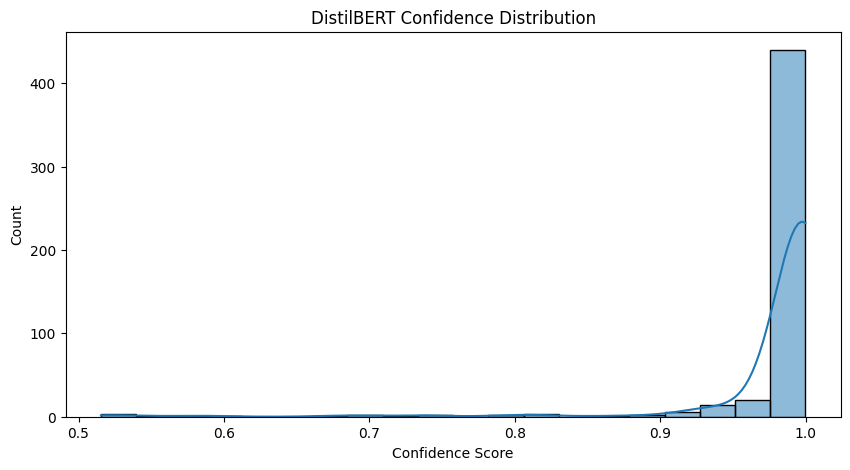

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

scores = [x['score'] for x in predictions]

plt.figure(figsize=(10,5))
sns.histplot(scores, bins=20, kde=True)

plt.title("DistilBERT Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Count")

plt.show()

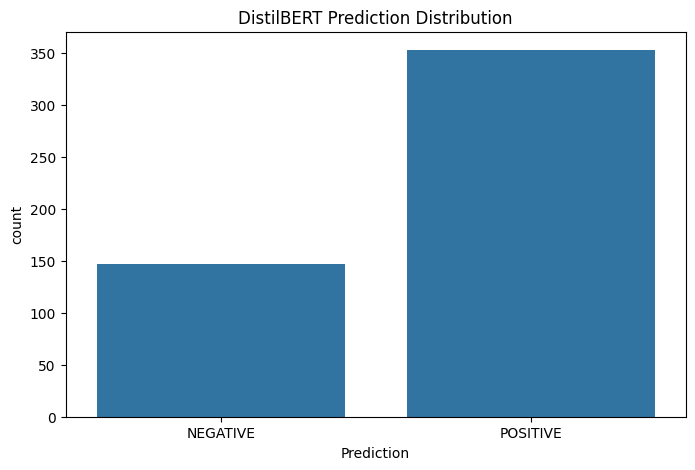

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pred_labels = [x['label'] for x in predictions]

pred_df = pd.DataFrame({
    'Prediction': pred_labels
})

plt.figure(figsize=(8,5))

sns.countplot(
    data=pred_df,
    x='Prediction'
)

plt.title("DistilBERT Prediction Distribution")

plt.show()

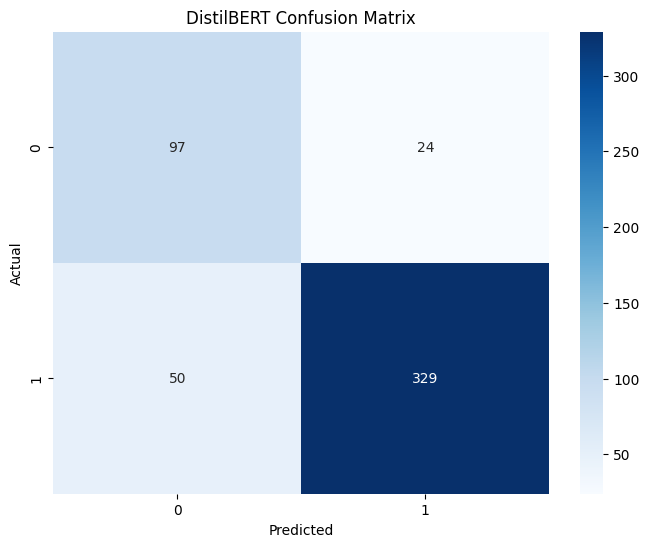

In [0]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, bert_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("DistilBERT Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

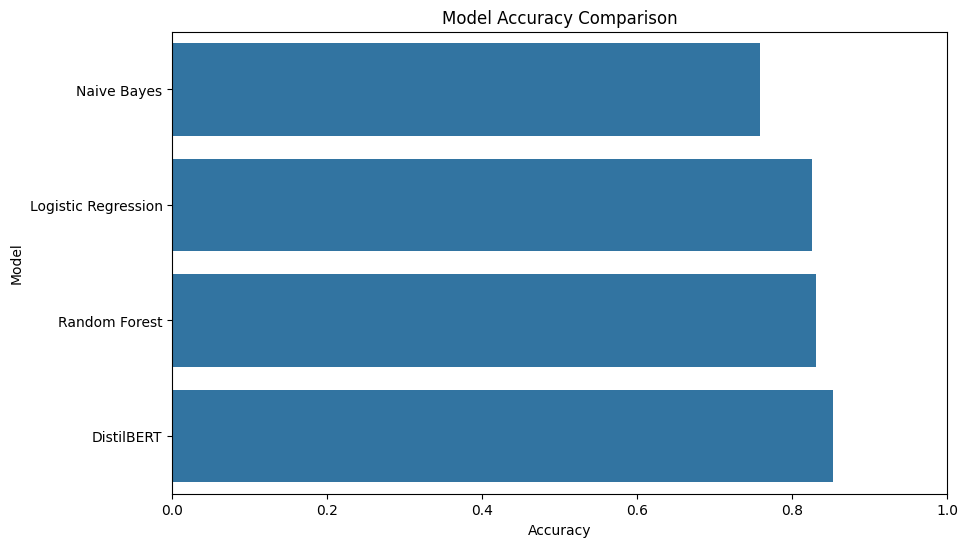

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x='Accuracy',
    y='Model'
)

plt.title("Model Accuracy Comparison")

plt.xlim(0,1)

plt.show()

In [0]:
review = """
The product is excellent but stopped working after one week
"""

result = sentiment_model(review)

print("Review:")
print(review)

print("\nPrediction:")
print(result[0]['label'])

print("\nConfidence:")
print(f"{result[0]['score']:.0f}")

Review:

The product is excellent but stopped working after one week


Prediction:
NEGATIVE

Confidence:
1
